# Variational Autoencoder for cat images

## Imports

In [ ]:
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from scripts import (
    DataFixedConfig,
    DataGridConfig,
    TrainFixedConfig,
    TrainGridConfig,
    VAEExperiment,
    VAEFixedConfig,
    VAEGridConfig,
    build_dataloaders,
    build_vae,
    compute_fid,
    count_parameters,
    expand_experiment_grid,
    interpolate_vae,
    output_paths,
    prepare_data,
    report_fid,
    run_name,
    sample_vae_latents,
    save_history,
    save_history_plot,
    save_interpolation_grid,
    save_json,
    save_sample_grid,
    train_vae,
    update_total_stats,
    vae_sample_iterator,
)

## Parameters

In [ ]:
# Training time on a free Colab T4 GPU at image_size=64 and ~14k cats:
#   batch_size=64, latent_dim=128, base_channels=32 -> ~30s per epoch.
#   30 epochs ~= 15 minutes total. Each beta sweep multiplies that by len(beta).

EXPERIMENT_NAME = "vae"

# --- Data ---------------------------------------------------------------
DATA_DIR = "../data/cats"
OUTPUT_DIR = "../reports/runs"
CACHE_DIR = "../.cache/fid"
IMAGE_SIZE = 32
TRAIN_FRACTION = 0.9
VALIDATION_FRACTION = 0.1
AUGMENT_FLIP = True

# --- Model --------------------------------------------------------------
LATENT_DIM = 128
HIDDEN_DIM = 512
BASE_CHANNELS = 32
BETA = 1.0

# --- Optimization -------------------------------------------------------
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 0.0
EPOCHS = 50
BATCH_SIZE = 64
SEED = 42

# --- Early stopping -----------------------------------------------------
# Aggressive: stop unless validation_loss improves by at least MIN_DELTA
# within PATIENCE epochs. Sub-MIN_DELTA wiggles are treated as noise.
EARLY_STOPPING = True
EARLY_STOPPING_PATIENCE = 5
EARLY_STOPPING_MIN_DELTA = 0.5
EARLY_STOPPING_RESTORE_BEST = True

# --- Logging / sampling -------------------------------------------------
SAMPLE_EVERY = 5
FID_REAL_SAMPLES = 1000
FID_FAKE_SAMPLES = 1000
DEVICE = "cuda"            # "auto" | "cpu" | "cuda"
PROGRESS_BACKEND = "terminal"  # "auto" | "notebook" | "terminal"

experiment = VAEExperiment(
    name=EXPERIMENT_NAME,
    data_fixed=DataFixedConfig(
        data_dir=DATA_DIR,
        cache_dir=CACHE_DIR,
        output_dir=OUTPUT_DIR,
        image_size=IMAGE_SIZE,
    ),
    data_grid=DataGridConfig(
        train_fraction=TRAIN_FRACTION,
        validation_fraction=VALIDATION_FRACTION,
        augment_flip=AUGMENT_FLIP,
        seed=SEED,
    ),
    train_fixed=TrainFixedConfig(
        device=DEVICE,
        progress_backend=PROGRESS_BACKEND,
        fid_real_samples=FID_REAL_SAMPLES,
        fid_fake_samples=FID_FAKE_SAMPLES,
        early_stopping=EARLY_STOPPING,
        early_stopping_patience=EARLY_STOPPING_PATIENCE,
        early_stopping_min_delta=EARLY_STOPPING_MIN_DELTA,
        early_stopping_restore_best=EARLY_STOPPING_RESTORE_BEST,
    ),
    train_grid=TrainGridConfig(
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        sample_every=SAMPLE_EVERY,
    ),
    model_fixed=VAEFixedConfig(
        base_channels=BASE_CHANNELS,
        hidden_dim=HIDDEN_DIM,
    ),
    model_grid=VAEGridConfig(
        latent_dim=LATENT_DIM,
        beta=BETA,
        learning_rate=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
    ),
)

runs = expand_experiment_grid(experiment)
run = runs[0]
print(f"Generated {len(runs)} configuration(s); the first is selected for this notebook run.")

## Setup

In [3]:
torch.manual_seed(run["data"]["seed"])
np.random.seed(run["data"]["seed"])

run_dir = run_name(experiment.kind, run)
paths = output_paths(experiment.name, experiment.data_fixed.output_dir, run_dir)
save_json(paths["configs"] / "run.json", {"experiment": experiment.name, **run})
print(f"Run output: {paths['root']}")

prepared = prepare_data(
    experiment.data_fixed,
    train_fraction=run["data"]["train_fraction"],
    validation_fraction=run["data"]["validation_fraction"],
    augment_flip=run["data"]["augment_flip"],
    seed=run["data"]["seed"],
)
print(f"Train images: {len(prepared.train_dataset)} | Validation: {len(prepared.validation_dataset)}")

train_loader, validation_loader = build_dataloaders(
    prepared,
    experiment.data_fixed,
    batch_size=run["train"]["batch_size"],
    seed=run["data"]["seed"],
)

model = build_vae(run["model"], experiment.model_fixed, experiment.data_fixed)
print(f"VAE parameters: {count_parameters(model):,}")


Run output: reports\runs\vae\vae_z128_b1_0_lr0_001_seed42_e50_bs64
Train images: 8994 | Validation: 999
VAE parameters: 2,628,867


## Training

In [ ]:
training_result = train_vae(
    model,
    train_loader,
    validation_loader,
    model_params=run["model"],
    train_params=run["train"],
    train_fixed=experiment.train_fixed,
    sample_dir=paths["samples"],
)

history = training_result["history"]
save_history(history, paths["metrics"] / "history.csv")
save_history_plot(
    history,
    paths["figures"] / "loss_curves.png",
    metrics=["loss", "validation_loss", "reconstruction", "kl"],
    title="VAE Loss Curves",
)
elapsed = training_result["elapsed_seconds"]
print(f"Trained in {int(elapsed // 3600):02d}:{int(elapsed % 3600 // 60):02d}:{int(elapsed % 60):02d} on {training_result['device']}.")
update_total_stats(
    experiment.data_fixed.output_dir,
    experiment.kind,
    run_dir,
    experiment.name,
    elapsed,
    training_result["device"],
)

## Evaluation

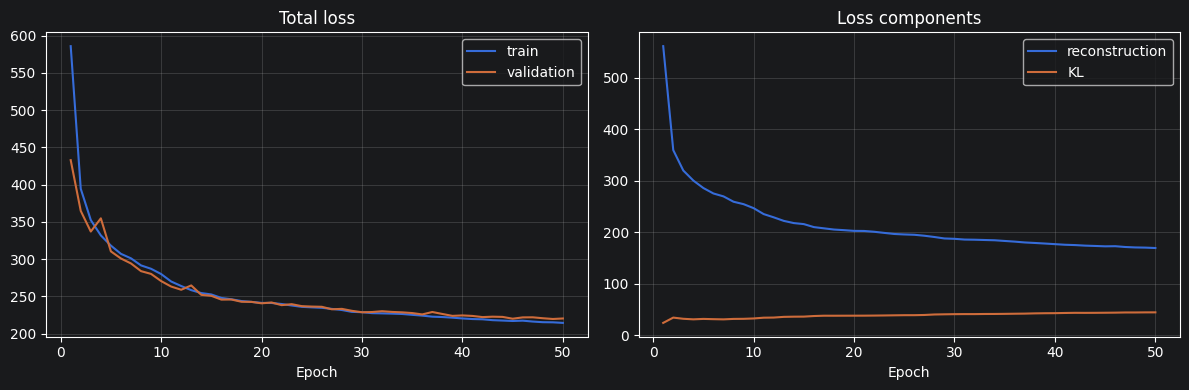

Generated → Inception: 0it [00:00, ?it/s]

FID: 187.657 (sampling took 15.0s)


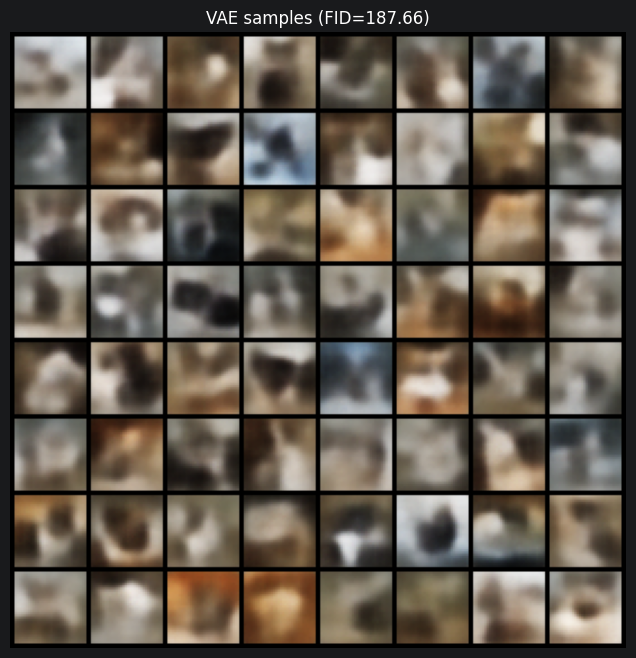

In [5]:
device = next(model.parameters()).device

with torch.no_grad():
    z = torch.randn(64, model.latent_dim, device=device)
    save_sample_grid(model.decode(z), paths["figures"] / "samples_final.png", nrow=8)

metrics_df = pd.DataFrame(history)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(metrics_df["epoch"], metrics_df["loss"], label="train")
axes[0].plot(metrics_df["epoch"], metrics_df["validation_loss"], label="validation")
axes[0].set_title("Total loss")
axes[0].set_xlabel("Epoch"); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(metrics_df["epoch"], metrics_df["reconstruction"], label="reconstruction")
axes[1].plot(metrics_df["epoch"], metrics_df["kl"], label="KL")
axes[1].set_title("Loss components")
axes[1].set_xlabel("Epoch"); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

sampler = vae_sample_iterator(
    model,
    num_samples=experiment.train_fixed.fid_fake_samples,
    batch_size=run["train"]["batch_size"],
    device=device,
    seed=run["data"]["seed"],
)
fid_start = time.perf_counter()
fid_score = compute_fid(
    sampler,
    experiment.data_fixed,
    num_real_samples=experiment.train_fixed.fid_real_samples,
    seed=run["data"]["seed"],
    device=device,
)
fid_elapsed = time.perf_counter() - fid_start
report_fid(fid_score, elapsed_seconds=fid_elapsed)
save_json(paths["metrics"] / "fid.json", {"fid": fid_score, "elapsed_seconds": fid_elapsed})

img = plt.imread(paths["figures"] / "samples_final.png")
plt.figure(figsize=(8, 8))
plt.imshow(img); plt.axis("off")
plt.title(f"VAE samples (FID={fid_score:.2f})")
plt.show()


## Interpolation

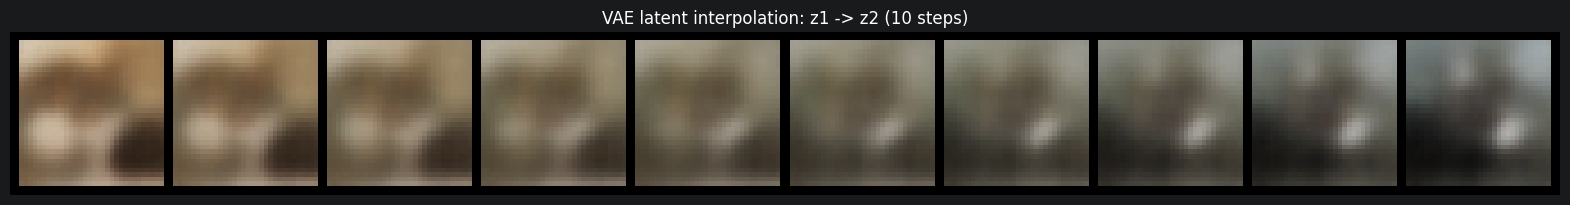

In [6]:
z1, z2 = sample_vae_latents(model, device, run["data"]["seed"])
images = interpolate_vae(model, z1, z2, num_steps=10)
interpolation_path = paths["figures"] / "interpolation.png"
save_interpolation_grid(images, interpolation_path)

img = plt.imread(interpolation_path)
plt.figure(figsize=(20, 2.6))
plt.imshow(img); plt.axis("off")
plt.title("VAE latent interpolation: z1 -> z2 (10 steps)")
plt.show()
